# **Imports**

In [12]:

from earthscape.utils.constants import VERSION, ASSETS_DIR, MODEL_DIR, SG_MAPPING
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import seaborn as sns

# **Setup**

In [2]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/segmentation'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)


# **Model Performance**

## *Single Modality Experiment Compilation*

In [41]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df.loc[idx, 'model'] = model_name
    df.loc[idx, 'encoder'] = encoder_name
    df.loc[idx, 'input'] = modalities
    df.loc[idx, id.columns] = id.values
    df.loc[idx, cd.columns] = cd.values


# save & display...
df.to_csv(output_path, index=False)
df.sort_values('micro_iou (id)', ascending=False).head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
70,segformer,mitb2,dem,0.489031,0.550684,0.616618,0.559820,0.780764,0.876887,0.876887,...,0.383654,0.440898,0.513953,0.461956,0.687296,0.814671,0.814671,0.814671,98.951378,82.651987
28,deeplabv3p,resnet50,s-5,0.475116,0.535211,0.595916,0.547041,0.766712,0.867953,0.867953,...,0.411731,0.467860,0.524283,0.480035,0.738597,0.849647,0.849647,0.849647,96.460381,79.841961
35,segformer,mitb0,dem,0.473483,0.535988,0.596516,0.552825,0.765678,0.867290,0.867290,...,0.395051,0.447822,0.515335,0.471019,0.719141,0.836628,0.836628,0.836628,97.559263,80.890456
133,unet,resnet18,s-5,0.450994,0.507200,0.576880,0.517709,0.763736,0.866044,0.866044,...,0.400427,0.454874,0.513998,0.466545,0.745687,0.854319,0.854319,0.854319,100.371829,79.895820
24,deeplabv3p,resnet50,s-10,0.480606,0.539703,0.603613,0.551728,0.762266,0.865098,0.865098,...,0.415956,0.468685,0.526025,0.482552,0.729383,0.843518,0.843518,0.843518,94.331813,77.795653


## *Multi-scale Experiment Compilation*

In [42]:
##################################################
# Compile Global Performance Metrics - Multiscale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df.loc[idx, 'model'] = model_name
    df.loc[idx, 'encoder'] = encoder_name
    df.loc[idx, 'input'] = modalities
    df.loc[idx, id.columns] = id.values
    df.loc[idx, cd.columns] = cd.values


# save & display...
df.to_csv(output_path, index=False)
df.sort_values('micro_iou (id)', ascending=False).head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
3,deeplabv3p,resnet50,s-ms,0.484805,0.544435,0.607743,0.557811,0.776282,0.874052,0.874052,...,0.423413,0.479090,0.531074,0.497234,0.749290,0.856679,0.856679,0.856679,96.302821,79.824426
13,segformer,mitb2,s-ms,0.487949,0.549833,0.613054,0.563375,0.774502,0.872923,0.872923,...,0.419074,0.477022,0.533200,0.494685,0.739963,0.850550,0.850550,0.850550,96.395804,79.443703
2,deeplabv3p,resnet50,prc-ms,0.482729,0.547748,0.609042,0.559647,0.770579,0.870426,0.870426,...,0.426060,0.487663,0.548741,0.506200,0.735658,0.847699,0.847699,0.847699,95.392149,78.768571
8,segformer,mitb0,s-ms,0.483059,0.545057,0.608899,0.556748,0.768890,0.869348,0.869348,...,0.413311,0.470766,0.525280,0.488505,0.737110,0.848662,0.848662,0.848662,96.600286,80.068046
18,unet,resnet18,s-ms,0.466991,0.526488,0.594906,0.536720,0.768451,0.869067,0.869067,...,0.422019,0.476414,0.529837,0.486034,0.763551,0.865925,0.865925,0.865925,99.694616,79.001542


## *Multimodal Experiment Compilation*

In [43]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multimodal_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df.loc[idx, 'model'] = model_name
    df.loc[idx, 'encoder'] = encoder_name
    df.loc[idx, 'input'] = modalities
    df.loc[idx, id.columns] = id.values
    df.loc[idx, cd.columns] = cd.values


# save & display...
df.to_csv(output_path, index=False)
df.sort_values('micro_iou (id)', ascending=False).head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
19,unet,resnet18,ep-ms+prc-ms+s-ms,0.498217,0.559482,0.620749,0.569213,0.801956,0.890095,0.890095,...,0.421719,0.479869,0.526230,0.494885,0.759270,0.863165,0.863165,0.863165,95.092682,75.278611
5,deeplabv3p,resnet50,prc-ms+s-ms,0.512490,0.575337,0.635278,0.583955,0.799682,0.888693,0.888692,...,0.463329,0.523455,0.574666,0.538645,0.776328,0.874082,0.874082,0.874082,88.370076,71.160174
23,unet,resnet18,prc-ms+s-ms,0.495536,0.557914,0.615054,0.570558,0.798920,0.888222,0.888222,...,0.417799,0.476382,0.529127,0.495688,0.749643,0.856909,0.856910,0.856910,97.683011,77.606396
1,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.517403,0.579121,0.642594,0.589566,0.798666,0.888065,0.888065,...,0.450268,0.509555,0.569154,0.523452,0.761464,0.864581,0.864581,0.864581,91.516889,73.818294
3,deeplabv3p,resnet50,ep-ms+s-ms+sds-ms,0.500392,0.561720,0.618571,0.571191,0.798437,0.887923,0.887923,...,0.443377,0.502536,0.556308,0.517657,0.769382,0.869662,0.869662,0.869662,90.872558,73.812591


## *All Experiments Compilation*

In [44]:
##################################################
# Compile All Global Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_global.csv")
ms_path = os.path.join(assets_dir, "multiscale_global.csv")
mm_path = os.path.join(assets_dir, "multimodal_global.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_global.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))
df_list.append(pd.read_csv(mm_path))

df = pd.concat(df_list)
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.sort_values('micro_iou (id)', ascending=False).head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
179,unet,resnet18,ep-ms+prc-ms+s-ms,0.498217,0.559482,0.620749,0.569213,0.801956,0.890095,0.890095,...,0.421719,0.479869,0.526230,0.494885,0.759270,0.863165,0.863165,0.863165,95.092682,75.278611
165,deeplabv3p,resnet50,prc-ms+s-ms,0.512490,0.575337,0.635278,0.583955,0.799682,0.888693,0.888692,...,0.463329,0.523455,0.574666,0.538645,0.776328,0.874082,0.874082,0.874082,88.370076,71.160174
183,unet,resnet18,prc-ms+s-ms,0.495536,0.557914,0.615054,0.570558,0.798920,0.888222,0.888222,...,0.417799,0.476382,0.529127,0.495688,0.749643,0.856909,0.856910,0.856910,97.683011,77.606396
161,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.517403,0.579121,0.642594,0.589566,0.798666,0.888065,0.888065,...,0.450268,0.509555,0.569154,0.523452,0.761464,0.864581,0.864581,0.864581,91.516889,73.818294
163,deeplabv3p,resnet50,ep-ms+s-ms+sds-ms,0.500392,0.561720,0.618571,0.571191,0.798437,0.887923,0.887923,...,0.443377,0.502536,0.556308,0.517657,0.769382,0.869662,0.869662,0.869662,90.872558,73.812591


## *Visualizations*

### Modality Rankings

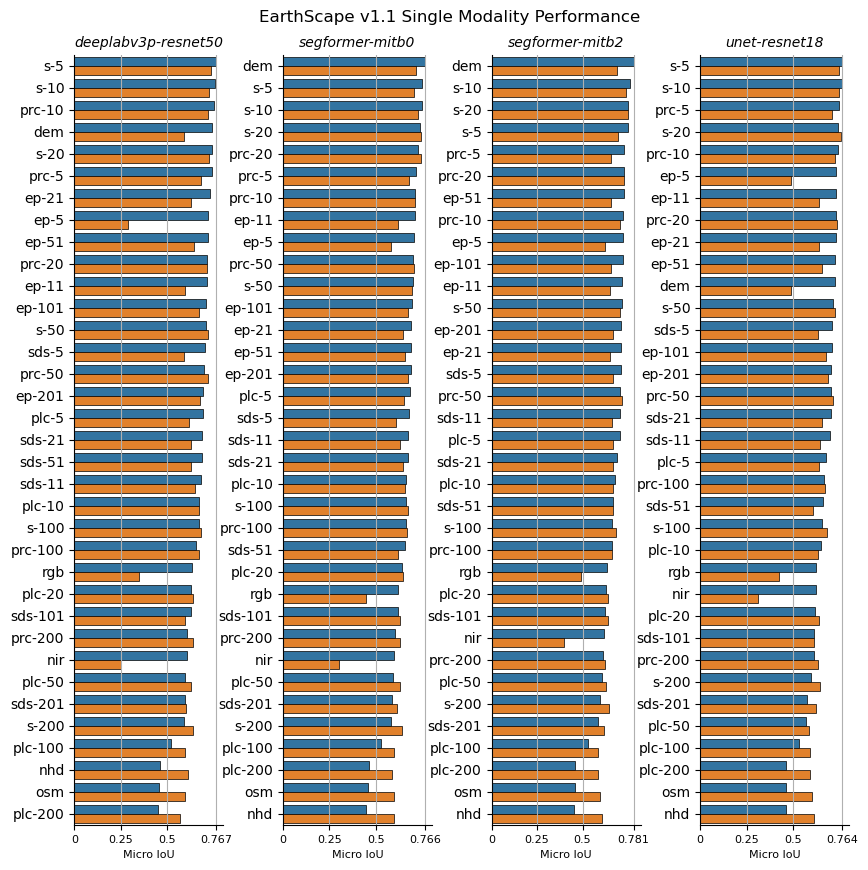

In [33]:
#############################################
# Modality Ranking Bar Charts - Single Modalitiy Experiments
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'single_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'iou'
metric_label = 'Micro IoU'

# models to use...
models = ['unet-resnet18', 'deeplabv3p-resnet50', 'segformer-mitb0', 'segformer-mitb2']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_single_iou.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(2.5*len(models),10))
plt.subplots_adjust(wspace=0.4)
ax = ax.ravel()

df_single['model-encoder'] = df_single['model'] + '-' + df_single['encoder']

idx = 0
for m in df_single['model-encoder'].unique():

    if m in models:

        df = df_single[df_single['model-encoder'] == m].copy()
        df.sort_values(f"micro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"micro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"micro_{metric} (id)", f"micro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Single Modality Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

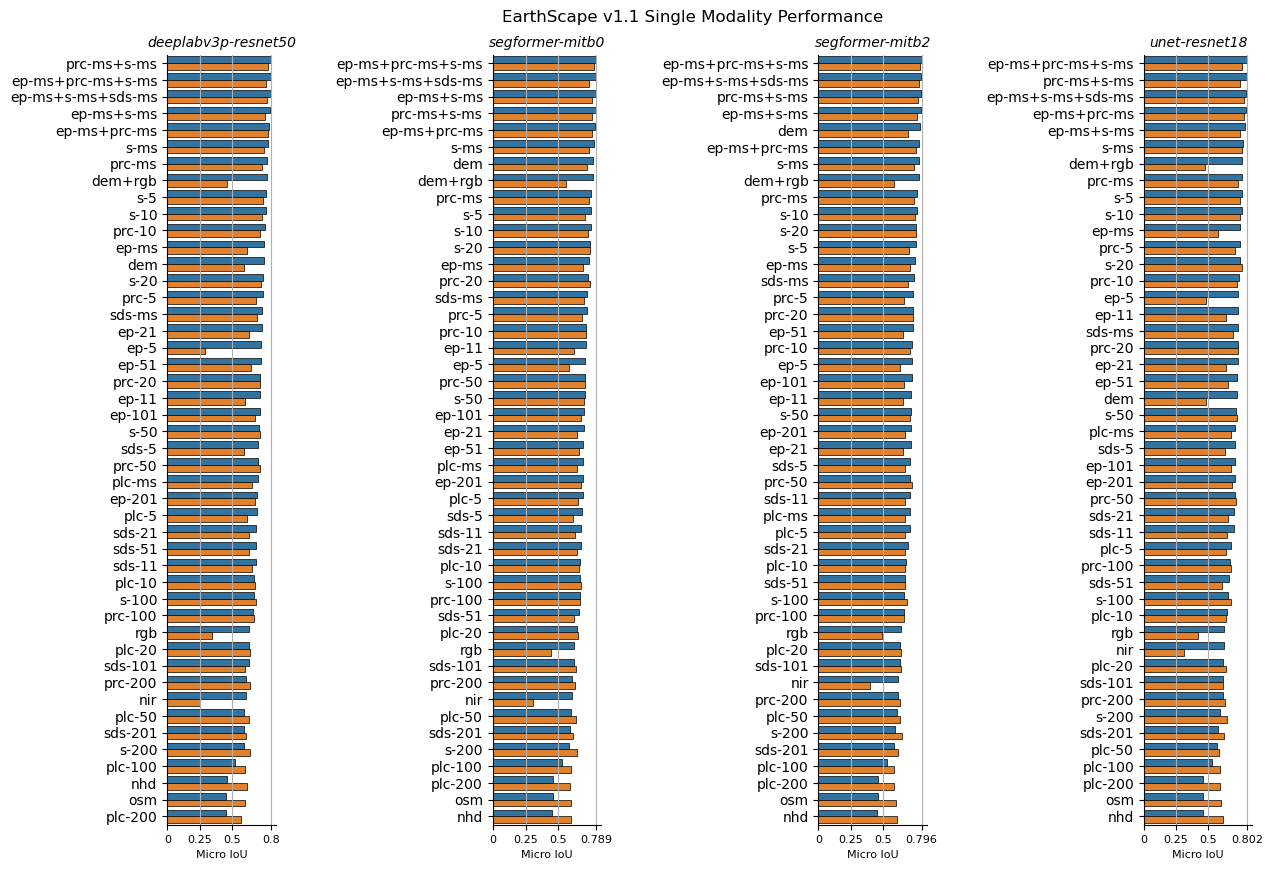

In [32]:
#############################################
# Modality Ranking Bar Charts - All Experiments
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'iou'
metric_label = 'Micro IoU'

# models to use...
models = ['unet-resnet18', 'deeplabv3p-resnet50', 'segformer-mitb0', 'segformer-mitb2']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_all_iou.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models), 10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

df_single['model-encoder'] = df_single['model'] + '-' + df_single['encoder']

idx = 0
for m in df_single['model-encoder'].unique():

    if m in models:

        df = df_single[df_single['model-encoder'] == m].copy()
        df.sort_values(f"micro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"micro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"micro_{metric} (id)", f"micro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Single Modality Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Scale Sensitivity

In [28]:
def parse_features(x):
    """Function to parse modality/input strings into modality family and ground sampling distance (GSD) or multi-scale (MS) configurations."""
    x_split = x.split('-')
    if len(x_split) == 1:
        return x_split[0], None
    elif len(x_split) == 2:
        return x_split[0], x_split[1]
    else:
        return 'multimodal', 'ms'
    

def spatial_support(x, bins, raw_gsd=5):
    """Function to group GSD features into families of effective area covered."""
    if x is not None:
        if str(x).isnumeric():
            for bin in bins:
                if np.isclose(int(x) * raw_gsd, bin, atol=10):
                    return bin
        else:
            return x
    else:
        return np.nan

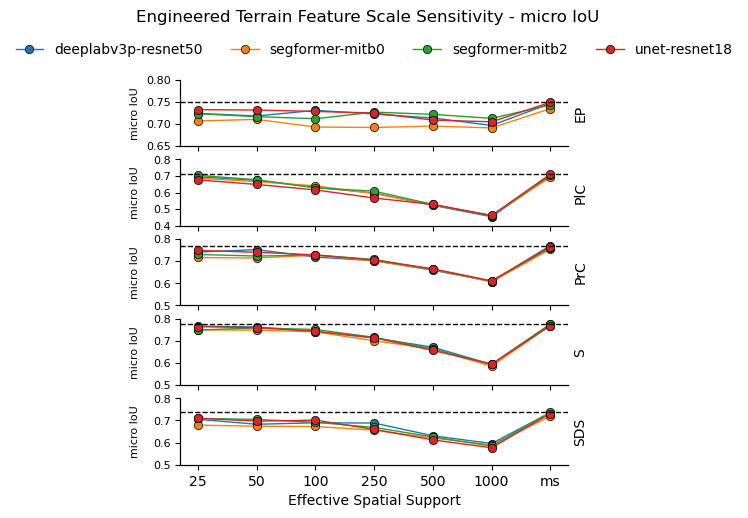

In [35]:
#############################################
# Terrain Feature Scale-Sensitivity - In-domain
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = 'micro IoU'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_iou_id.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model-encoder'].unique():
        df = subset[subset['model-encoder'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"micro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    max_val = subset[f"micro_{metric} (id)"].max()
    ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(f"{metric_label}", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Effective Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label}", y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

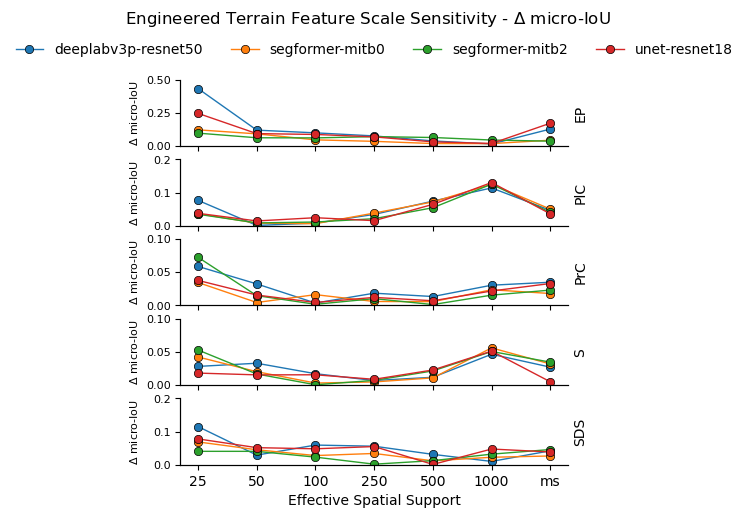

In [45]:
#############################################
# Terrain Feature Scale-Sensitivity - Delta
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = r'$\Delta$ micro-IoU'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_delta_id.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']

df_compiled['delta'] = np.abs(df_compiled[f"micro_{metric} (id)"] - df_compiled[f"micro_{metric} (cd)"])

##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model-encoder'].unique():
        df = subset[subset['model-encoder'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"delta"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    # min_val = subset['delta'].min()
    # ax[idx].axhline(y=min_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylim(0)
    ax[idx].set_ylabel(f"{metric_label}", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Effective Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label}", y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Cross-domain Robustness

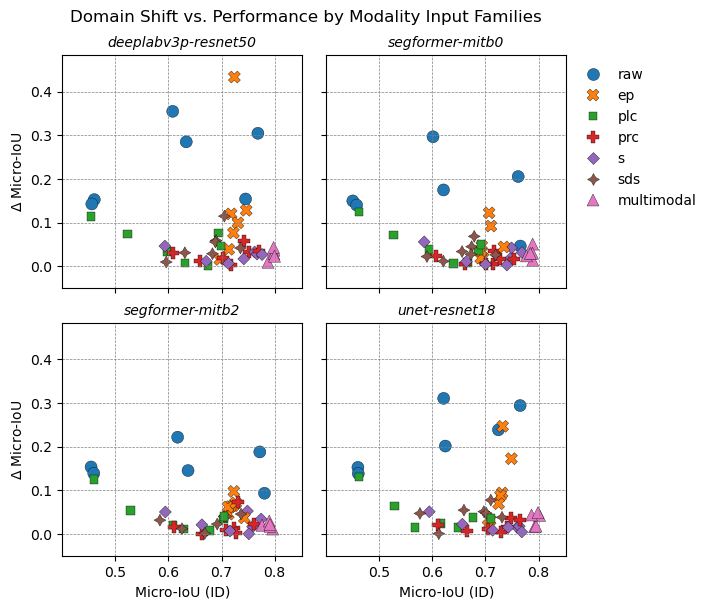

In [51]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = 'Micro-IoU'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_scatter_delta.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled['delta'] = np.abs(df_compiled[f"micro_{metric} (id)"] - df_compiled[f"micro_{metric} (cd)"])

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"micro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"micro_{metric} (id)"].max() + 0.05
ymin = df_compiled['delta'].min() - 0.05
ymax = df_compiled['delta'].max() + 0.05

# iterate over model architectures...
models = df_compiled['model-encoder'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model-encoder'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"micro_{metric} (id)", y='delta', hue='family', style='family', s=75, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(ymin, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ylab = r'$\Delta$ ' + f"{metric_label}"
    ax[idx].set_ylabel(ylab)
    # if 'resnet' in m:
    #     name = 'ResNet' + m[-2:]
    #     ax[idx].set_title(name, style='italic', fontsize=10)
    # elif 'vit' in m:
    #     ax[idx].set_title('ViT', style='italic', fontsize=10)
    # elif 'swin' in m:
    #     ax[idx].set_title('Swin', style='italic', fontsize=10)
    ax[idx].set_title(subset['model-encoder'].unique().item(), style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Domain Shift vs. Performance by Modality Input Families', y=0.95)

# save and show...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# **Class-wise Performance**

## *Single Modality Experiment Compilation*

In [80]:
##################################################
# Compile Per-Class Performance Metrics - Single
##################################################

# output path for compilation
output_path = os.path.join(assets_dir, 'single_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_all = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_all = pd.concat([df_all, df], ignore_index=True, axis=0)
    df_all.loc[idx:idx+(len(df)), 'model'] = model_name
    df_all.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_all.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# save & display...
df_all.to_csv(output_path, index=False)
df_all.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem,Qal,8361713.0,7536136.0,947.0,928.0,5980234.0,1555902.0,...,0.137092,0.188426,0.314983,0.180292,141.442329,126.829787,0.228576,0.372099,0.608144,0.268055
2,deeplabv3p,resnet50,dem,Qat,388848.0,268789.0,61.0,60.0,94148.0,174641.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem,Qc,16237424.0,17202215.0,748.0,807.0,14663487.0,2538728.0,...,0.213697,0.275945,0.229029,0.435821,130.693717,111.436685,0.434113,0.605410,0.445544,0.944196
4,deeplabv3p,resnet50,dem,Qca,7202703.0,5861922.0,431.0,419.0,3971679.0,1890243.0,...,0.028692,0.045314,0.126181,0.039797,172.521181,158.150522,0.069393,0.129781,0.146740,0.116336


## *Multi-scale Experiment Compilation*

In [81]:
##################################################
# Compile Per-Class Performance Metrics - Multi-scale
##################################################

# output path for compilation
output_path = os.path.join(assets_dir, 'multiscale_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_all = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_all = pd.concat([df_all, df], ignore_index=True, axis=0)
    df_all.loc[idx:idx+(len(df)), 'model'] = model_name
    df_all.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_all.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# save & display...
df_all.to_csv(output_path, index=False)
df_all.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,ep-ms,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,ep-ms,Qal,8361713.0,8199411.0,947.0,1054.0,6680436.0,1518975.0,...,0.303881,0.375916,0.371760,0.473266,120.295557,104.006573,0.514143,0.679121,0.552783,0.880316
2,deeplabv3p,resnet50,ep-ms,Qat,388848.0,539226.0,61.0,109.0,172118.0,367108.0,...,0.016082,0.024768,0.063236,0.026466,178.579663,167.108281,0.045650,0.087315,0.067224,0.124535
3,deeplabv3p,resnet50,ep-ms,Qc,16237424.0,15833644.0,748.0,706.0,13838003.0,1995641.0,...,0.004168,0.006639,0.065462,0.004968,224.932480,206.073399,0.005830,0.011593,0.433847,0.005875
4,deeplabv3p,resnet50,ep-ms,Qca,7202703.0,5329902.0,431.0,371.0,3621076.0,1708826.0,...,0.008422,0.011123,0.017571,0.013183,185.029811,175.860970,0.020005,0.039224,0.168537,0.022195


## *Multimodal Experiment Compilation*

In [82]:
##################################################
# Compile Per-Class Performance Metrics - Multimodal
##################################################

# output path for compilation
output_path = os.path.join(assets_dir, 'multimodal_class.csv')


##### compile in- & cross-domain data...
# initialize df
df_all = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in mm_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_all = pd.concat([df_all, df], ignore_index=True, axis=0)
    df_all.loc[idx:idx+(len(df)), 'model'] = model_name
    df_all.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_all.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)

# save & display...
df_all.to_csv(output_path, index=False)
df_all.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem+rgb,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem+rgb,Qal,8361713.0,7783900.0,947.0,945.0,6189999.0,1593901.0,...,0.021206,0.033100,0.132261,0.023510,158.595136,148.114965,0.024281,0.047411,0.734611,0.024496
2,deeplabv3p,resnet50,dem+rgb,Qat,388848.0,201869.0,61.0,55.0,74447.0,127422.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem+rgb,Qc,16237424.0,15958691.0,748.0,781.0,14308856.0,1649835.0,...,0.084895,0.124819,0.287199,0.112029,172.168721,156.376829,0.133184,0.235061,0.611706,0.145483
4,deeplabv3p,resnet50,dem+rgb,Qca,7202703.0,6794139.0,431.0,424.0,4537760.0,2256379.0,...,0.022104,0.034479,0.136336,0.027778,182.633431,170.731542,0.041124,0.078999,0.194659,0.049555


## *All Experiments Compilation*

In [83]:
##################################################
# Compile All Global Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_class.csv")
ms_path = os.path.join(assets_dir, "multiscale_class.csv")
mm_path = os.path.join(assets_dir, "multimodal_class.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_class.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))
df_list.append(pd.read_csv(mm_path))

df = pd.concat(df_list)
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem,Qal,8361713.0,7536136.0,947.0,928.0,5980234.0,1555902.0,...,0.137092,0.188426,0.314983,0.180292,141.442329,126.829787,0.228576,0.372099,0.608144,0.268055
2,deeplabv3p,resnet50,dem,Qat,388848.0,268789.0,61.0,60.0,94148.0,174641.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem,Qc,16237424.0,17202215.0,748.0,807.0,14663487.0,2538728.0,...,0.213697,0.275945,0.229029,0.435821,130.693717,111.436685,0.434113,0.605410,0.445544,0.944196
4,deeplabv3p,resnet50,dem,Qca,7202703.0,5861922.0,431.0,419.0,3971679.0,1890243.0,...,0.028692,0.045314,0.126181,0.039797,172.521181,158.150522,0.069393,0.129781,0.146740,0.116336


## *Visualizations*

### Class-wise Top K Bar Chart

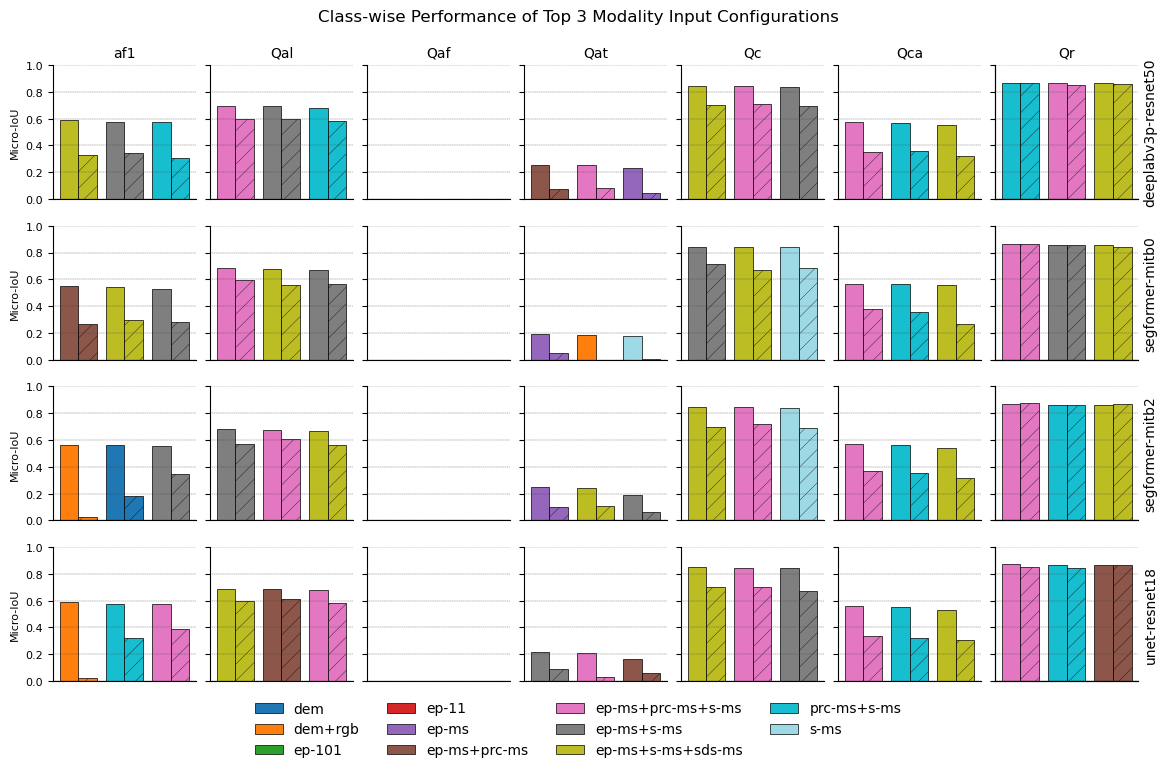

In [24]:
#############################################
# Class Domain Shift Performance for Top K Modality Configurations
#############################################

# path to compiled per-class performance data
class_path = os.path.join(assets_dir, 'compiled_class.csv')

# metric & metric label to use...
metric = 'iou'
metric_label = 'Micro-IoU'

# number of top K performing modalities to plot
top_k = 3

# bar width for plot
bar_width = 0.4

# output path
output_path = os.path.join(assets_dir, 'class_topk_performance.png')


##### pre-processing...
df_class = pd.read_csv(class_path)
df_class['model-encoder'] = df_class['model'] + '-' + df_class['encoder']
models = df_class['model-encoder'].unique()
classes = list(SG_MAPPING.keys())

# get top K performing modality configurations for each model and class...
df_top_k = df_class\
    .sort_values(['model-encoder', 'class', f"micro_{metric} (id)"], ascending=[True, True, False])\
        .groupby(['model-encoder', 'class'], as_index=False)\
            .head(top_k)\
                .copy()

# list of unique top K modality configs
top_k_inputs = sorted(df_top_k['input'].unique())

# create color map for modality configs...
base_cmap = plt.get_cmap('tab20')
color_vals = np.linspace(0, 1, len(top_k_inputs))
cmap = {inp: base_cmap(val) for inp, val in zip(top_k_inputs, color_vals)}


##### plot...
fig, ax = plt.subplots(ncols=len(classes), nrows=len(models), sharey=True, figsize=(2*len(classes), 2*len(models)))
fig.subplots_adjust(wspace=0.1)
ax = ax.ravel()

# iterate through each model (each model on separate row)...
row = 0
for m in models:

    # iterate through each class (each class in separate column)...
    for col, c in enumerate(classes):

        # update subplot index by combining row and col
        idx = row + col

        # subset df for model & class of interest & top K modality configs....
        mask = (df_class['model-encoder'] == m) & (df_class['class'] == c)
        subset = df_class[mask].copy()
        subset.sort_values(f"micro_{metric} (id)", ascending=False, inplace=True)
        subset.reset_index(drop=True, inplace=True)
        subset = subset.loc[:top_k-1]

        # numeric x axis
        x = np.arange(top_k)

        # relevant colors from custom color map
        # colors = [cmap[i] for i in subset['input']]
        colors = [cmap[i] if i in cmap.keys() else '0.5' for i in subset['input']]
        
        # plot in-domain & cross-domain (hatched) bars...
        ax[idx].bar(x=x - bar_width/2, height=subset[f"micro_{metric} (id)"], width=bar_width, linewidth=0.5, edgecolor='k', facecolor=colors)
        ax[idx].bar(x=x + bar_width/2, height=subset[f"micro_{metric} (cd)"], width=bar_width, linewidth=0.5, edgecolor='k', facecolor=colors, hatch='//', hatch_linewidth=0.25)

        # customize plot...
        ax[idx].set_xticks([])
        ax[idx].set_xlabel('')
        ax[idx].grid(axis='y', linewidth=0.25, linestyle='--', color='0.25')
        ax[idx].spines['right'].set_visible(False)
        ax[idx].spines['top'].set_visible(False)

    # plot model name on other y axis...
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(m)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # increase row index count
    row += 7

# set class name as title for first row... 
for idx, c in enumerate(classes):
    ax[idx].set_title(c, fontsize=10)

# set y-axis text for first column...
for axes in ax[[0,7,14,21]]:
    axes.set_yticks(np.arange(0, 1.1, 0.2))
    axes.set_yticklabels(ax[0].get_yticklabels(), fontsize=8)
    axes.set_ylabel(f"{metric_label}", fontsize=8)

# create custom legend...
handles = [Patch(facecolor=color, edgecolor='k', linewidth=0.5, label=inp) for inp, color in cmap.items()]
fig.legend(handles=handles, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 0.1), ncols=4)

# figure title
plt.suptitle(f"Class-wise Performance of Top {top_k} Modality Input Configurations", y=0.95, fontsize=12)

# save and show plot...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Performance vs. Class-area Proportion

In [ ]:
#############################################
# Model Prediction vs. Exposed Class Area
#############################################

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'



# relevant experiment directories (modality config fun in all models)
exp_dirs = glob.glob(f"../experiments/baselines/classification/multimodal/*{exp}*")



# model predictions of in-domain test set
pred_paths = [os.path.join(d, 'predictions_id.csv') for d in exp_dirs]



# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# ouput path
output_path = os.path.join(assets_dir, 'iou_vs_area.png')



##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)


# set up figure...one subplot for each model
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(16,4))


# iterate through each model experiment...
for idx, path in enumerate(pred_paths):

    model = os.path.dirname(path)
    model = os.path.basename(model).split('_')[0]
    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    df = preds.merge(right=areas, how='left', on='patch_id', suffixes=['', '_area'])    # merge with area proportions
    df.set_index('patch_id', drop=True, inplace=True)                                   # reset index using patch_id


    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]


    # iterate through each class...
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()                                              # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]                                                # only process patches with class presence
        bins = np.arange(0, 1.05, 0.1)                                       # define bins
        df2['area_bin'] = pd.cut(df2[a], bins=bins, include_lowest=True)     # create bin categories

        # plot lowess curve...
        sns.regplot(ax=ax[idx], data=df2, x=a, y=p, lowess=True, scatter=False, label=p)

    # customize plot...
    ax[idx].legend(loc='lower right', bbox_to_anchor=(1, 0), frameon=False, fontsize=8, title='LOWESS')
    ax[idx].set_title(model)
    ticks = np.arange(0, 1.01, 0.2)
    ax[idx].set_xlabel('Class Area Proportion')
    ax[idx].set_xticks(ticks)
    ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
    ax[idx].set_yticks(ticks)
    ax[idx].set_yticklabels([])
    ax[idx].set_ylabel('')
    ax[idx].grid(axis='both', linewidth=0.5, linestyle='--')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

# set y axis for first plot...
ax[0].set_ylabel('IoU')
ax[0].set_yticks(ticks)
ax[0].set_yticklabels([str(round(s, 1)) for s in ticks], fontsize=8)

# save and show...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# **Sample Performance**

## *Masks by Performance Category Examples*

In [ ]:

# filter df...
# 1. two or more GT classes
# 2. area of GT classes >= 0.05 or 0.1 or...???


# define performance bins...
# 1. IoU of <0.25, 0.25-0.5, 0.5-0.75, >0.75 ???


# randomly select samples from each performance bin...
# 1. load model
# 2. use model to evaluate sample
# 3. create mask


# plot...
# 1. GT mask
# 2. Predicted mask